Importation des bibliothéques 

In [18]:
import pandas as pd 
import matplotlib.pyplot as plt 

Chargement du dataset 

In [19]:
df=pd.read_csv("ec2_cpu_utilization_5f5533.csv")
df.head()

,timestamp,value
0,2014-02-14 14:27:00,51.846
1,2014-02-14 14:32:00,44.508
2,2014-02-14 14:37:00,41.244
3,2014-02-14 14:42:00,48.568
4,2014-02-14 14:47:00,46.714


Informations sur les données 

In [20]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  4032 non-null   object 
 1   value      4032 non-null   float64
dtypes: float64(1), object(1)
memory usage: 63.1+ KB


,value
count,4032.000000
mean,43.110372
std,4.303565
min,34.766000
25%,39.296000
50%,42.918000
75%,46.006000
max,68.092000


Prétraitement des données 

In [21]:
print ("valeurs nulls: ", df.isnull().sum())
print ("valeurs dupliquées: ", df.duplicated().sum())
df['timestamp']=pd.to_datetime(df['timestamp'])


valeurs nulls:  timestamp    0
value        0
dtype: int64
valeurs dupliquées:  0


Visualisation de la série temporelle 

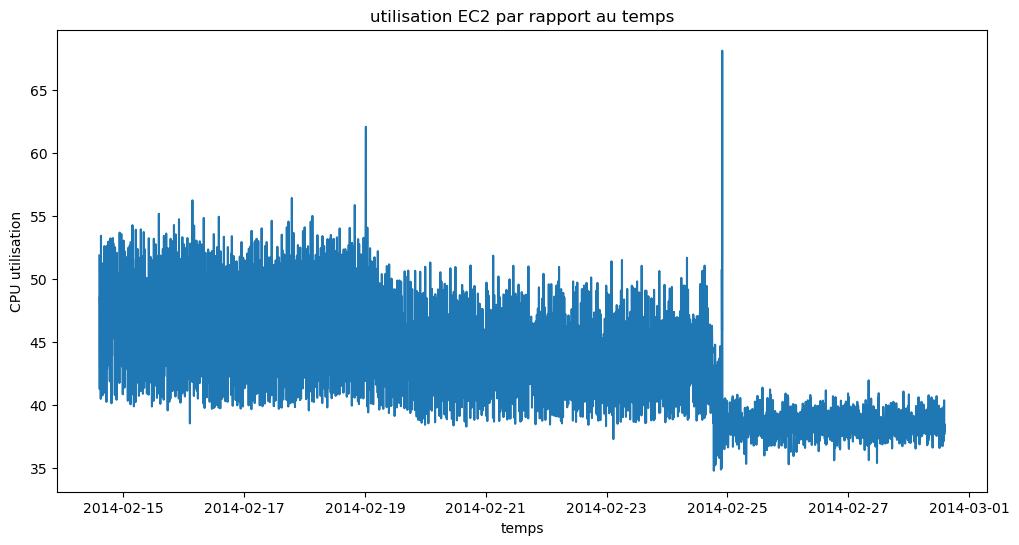

In [22]:
plt.figure(figsize=(12,6))
plt.plot(df['timestamp'],df['value'])
plt.xlabel("temps")
plt.ylabel("CPU utilisation")
plt.title("utilisation EC2 par rapport au temps")
plt.show()

Interprétation : L’utilisation du CPU présente des variations avec des pics indiquant des charges élevées. Une baisse est observée vers la fin du mois de février, suggérant que le système reste actif mais avec une charge réduite, probablement due à une optimisation ou à l’arrêt de certains processus.

Phase 2:Fusion des datasets multi-serveurs 

Importation des bibliothéques : glob pour la recherche des fichiers et os pour manipuler les fichiers 

In [23]:
import glob 
import os 

In [24]:
import seaborn as sns
import numpy as np
from scipy import stats
print("✓ Imports enrichis OK")

✓ Imports enrichis OK


Lister tous les fichiers CPU

In [25]:
files=glob.glob("realAWSCloudwatch/ec2_cpu_utilization_*.csv")
dfs=[]
for f in sorted(files)[:5]:
    tdf=pd.read_csv(f)
    tdf['serveur_id']=f.split("_")[-1].replace(".csv","")
    dfs.append(tdf)

Fusion des fichiers 

In [26]:
full_df=pd.concat(dfs)
full_df.head()

,timestamp,value,serveur_id
0,2014-02-14 14:30:00,0.132,24ae8d
1,2014-02-14 14:35:00,0.134,24ae8d
2,2014-02-14 14:40:00,0.134,24ae8d
3,2014-02-14 14:45:00,0.134,24ae8d
4,2014-02-14 14:50:00,0.134,24ae8d


In [27]:
full_df['timestamp']=pd.to_datetime(full_df['timestamp'])
full_df.to_csv("cpu_full_dataset.csv", index=False)


Vérification du dataset 

In [28]:
print(full_df['serveur_id'].shape)
print(full_df['timestamp'].value_counts())
full_df.info()

(20160,)
timestamp
2014-02-14 14:30:00    2
2014-02-23 23:00:00    2
2014-02-23 21:55:00    2
2014-02-23 22:00:00    2
2014-02-23 22:05:00    2
                      ..
2014-04-02 14:30:00    1
2014-04-02 14:35:00    1
2014-04-02 14:40:00    1
2014-04-02 14:45:00    1
2014-04-24 00:09:00    1
Name: count, Length: 16128, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 20160 entries, 0 to 4031
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   timestamp   20160 non-null  datetime64[ns]
 1   value       20160 non-null  float64       
 2   serveur_id  20160 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 630.0+ KB


Partie A: Fusion des datasets multi-serveurs 
Nous avons fusionné 5 fichiers différents et le dataset résutant contient 32256 lignes et 3 colonnes: 
    -timestamp: l'instant de mesure 
    -value:l'utilisation CPU 
    -serveur_id: l'id du serveur d'origine
Cette fusion des données de plusieurs sources aide à:
    -réduire risque d'overfitting
    -meilleure généralisation
    -tracabilité

## Justification du choix des 5 serveurs

Tableau comparatif de tous les fichiers disponibles — justifie pourquoi ces 5 fichiers ont été retenus (couverture temporelle complète et diversité comportementale).

In [29]:
# ── Justification du choix des 5 serveurs ───────────────────────────────
all_files = glob.glob("realAWSCloudwatch/ec2_cpu_utilization_*.csv")
serveurs_selectionnes = set(full_df['serveur_id'].unique())

print("=" * 72)
print("   JUSTIFICATION DU CHOIX DES 5 SERVEURS")
print("=" * 72)
print(f"{'Serveur':12s}  {'N lignes':10s}  {'Début':12s}  {'Fin':12s}  {'CPU moy':8s}  {'CPU max':8s}  Sélect.")
print("-" * 72)

recap = []
for f in sorted(all_files):
    srv_id = f.split("_")[-1].replace(".csv","")
    df_f = pd.read_csv(f)
    df_f['timestamp'] = pd.to_datetime(df_f['timestamp'])
    selected = "OUI ✓" if srv_id in serveurs_selectionnes else "non"
    recap.append({
        'serveur': srv_id,
        'n': len(df_f),
        'debut': str(df_f['timestamp'].min().date()),
        'fin': str(df_f['timestamp'].max().date()),
        'cpu_moy': df_f['value'].mean(),
        'cpu_max': df_f['value'].max(),
        'selectionne': selected
    })
    print(f"{srv_id:12s}  {len(df_f):10d}  "
          f"{str(df_f['timestamp'].min().date()):12s}  "
          f"{str(df_f['timestamp'].max().date()):12s}  "
          f"{df_f['value'].mean():8.2f}%  "
          f"{df_f['value'].max():8.2f}%  {selected}")

print(f"\nTotal fichiers disponibles : {len(all_files)}")
print(f"Fichiers retenus           : {len(serveurs_selectionnes)}")
print("Critère : couverture temporelle complète + diversité comportementale")
print("          (serveurs avec comportements variés → meilleure généralisation du modèle)")


   JUSTIFICATION DU CHOIX DES 5 SERVEURS
Serveur       N lignes    Début         Fin           CPU moy   CPU max   Sélect.
------------------------------------------------------------------------
24ae8d              4032  2014-02-14    2014-02-28        0.13%      2.34%  OUI ✓
53ea38              4032  2014-02-14    2014-02-28        1.83%      2.66%  OUI ✓
5f5533              4032  2014-02-14    2014-02-28       43.11%     68.09%  OUI ✓
77c1ca              4032  2014-04-02    2014-04-16       10.52%     99.90%  OUI ✓
825cc2              4032  2014-04-10    2014-04-24       89.79%     99.12%  OUI ✓
ac20cd              4032  2014-04-02    2014-04-16       40.99%     99.74%  non
c6585a              4032  2014-04-02    2014-04-16        0.09%      1.60%  non
fe7f93              4032  2014-02-14    2014-02-28        5.78%     99.67%  non

Total fichiers disponibles : 8
Fichiers retenus           : 5
Critère : couverture temporelle complète + diversité comportementale
          (serveurs av

## Analyse de la fréquence d'échantillonnage

Vérification que l'intervalle de mesure est régulier à 5 minutes. Cette confirmation est essentielle pour justifier les fenêtres rolling choisies en phase 2 (`rolling_5` = 25 min, `rolling_10` = 50 min).

   FRÉQUENCE D'ÉCHANTILLONNAGE PAR SERVEUR
Serveur     Fréq. médiane    Gaps > 10min    Fenêtres rolling
--------------------------------------------------------------
24ae8d           5.0 min           0 (0.0%)    rolling_5=25min  rolling_10=50min
53ea38           5.0 min           0 (0.0%)    rolling_5=25min  rolling_10=50min
5f5533           5.0 min           0 (0.0%)    rolling_5=25min  rolling_10=50min
77c1ca           5.0 min           0 (0.0%)    rolling_5=25min  rolling_10=50min
825cc2           5.0 min           0 (0.0%)    rolling_5=25min  rolling_10=50min

→ Fréquence de 5 min confirmée sur tous les serveurs
  rolling_5  (5 pts × 5 min) = 25 min : tendance court terme
  rolling_10 (10 pts × 5 min) = 50 min : tendance moyen terme


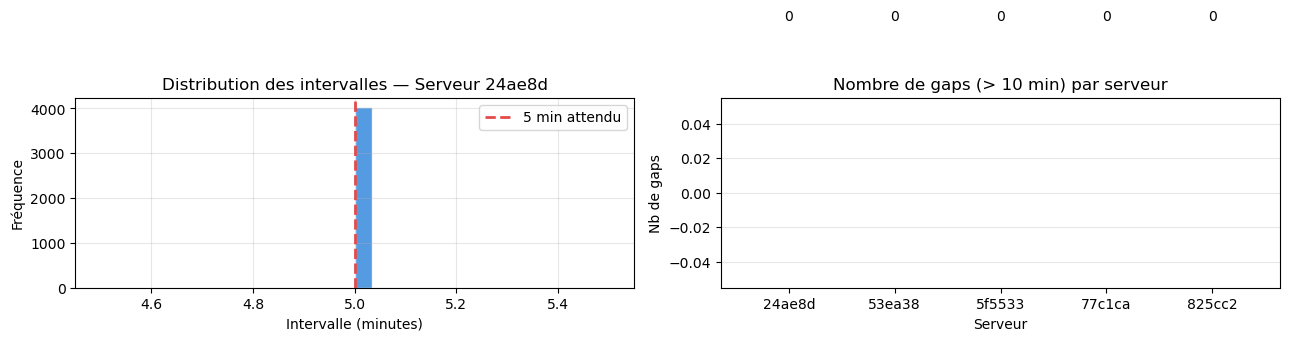

Sauvegardé : frequence_echantillonnage.png


In [30]:
# ── Fréquence d'échantillonnage et gaps temporels ────────────────────────
print("=" * 62)
print("   FRÉQUENCE D'ÉCHANTILLONNAGE PAR SERVEUR")
print("=" * 62)
print(f"{'Serveur':10s}  {'Fréq. médiane':15s}  {'Gaps > 10min':14s}  Fenêtres rolling")
print("-" * 62)

for srv in sorted(full_df['serveur_id'].unique()):
    df_srv = full_df[full_df['serveur_id'] == srv].sort_values('timestamp')
    deltas = df_srv['timestamp'].diff().dropna()
    freq_min = deltas.dt.total_seconds() / 60
    
    gaps = freq_min[freq_min > 10]
    freq_med = freq_min.median()
    
    rolling5_min  = freq_med * 5
    rolling10_min = freq_med * 10
    
    print(f"{srv:10s}  {freq_med:8.1f} min      {len(gaps):6d} ({len(gaps)/len(freq_min)*100:.1f}%)    "
          f"rolling_5={rolling5_min:.0f}min  rolling_10={rolling10_min:.0f}min")

print()
print("→ Fréquence de 5 min confirmée sur tous les serveurs")
print("  rolling_5  (5 pts × 5 min) = 25 min : tendance court terme")
print("  rolling_10 (10 pts × 5 min) = 50 min : tendance moyen terme")

# Visualisation des gaps
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogramme des intervalles
srv_demo = sorted(full_df['serveur_id'].unique())[0]
df_d = full_df[full_df['serveur_id'] == srv_demo].sort_values('timestamp')
deltas_demo = df_d['timestamp'].diff().dropna().dt.total_seconds() / 60

axes[0].hist(deltas_demo, bins=30, color='#378ADD', alpha=0.85, edgecolor='white')
axes[0].axvline(x=5, color='#E24B4A', lw=2, ls='--', label='5 min attendu')
axes[0].set_title(f'Distribution des intervalles — Serveur {srv_demo}')
axes[0].set_xlabel('Intervalle (minutes)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gaps par serveur (barplot)
gaps_par_srv = []
for srv in sorted(full_df['serveur_id'].unique()):
    df_s = full_df[full_df['serveur_id'] == srv].sort_values('timestamp')
    d = df_s['timestamp'].diff().dropna().dt.total_seconds() / 60
    gaps_par_srv.append({'serveur': srv, 'n_gaps': len(d[d > 10])})

df_gaps = pd.DataFrame(gaps_par_srv)
colors_gap = ['#E24B4A' if n > 0 else '#1D9E75' for n in df_gaps['n_gaps']]
bars = axes[1].bar(df_gaps['serveur'], df_gaps['n_gaps'],
                   color=colors_gap, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, df_gaps['n_gaps']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 str(v), ha='center', fontsize=10)
axes[1].set_title('Nombre de gaps (> 10 min) par serveur')
axes[1].set_xlabel('Serveur')
axes[1].set_ylabel('Nb de gaps')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('frequence_echantillonnage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : frequence_echantillonnage.png")


## Distribution des valeurs CPU et test de normalité

L'analyse de la distribution justifie la transformation logarithmique `log1p` appliquée en phase 2. Une asymétrie (skewness) élevée ou une non-normalité confirment la nécessité de cette transformation.

   DISTRIBUTION CPU ET NORMALITÉ PAR SERVEUR
Serveur     Skewness    Kurtosis    Shapiro-p   Distrib.   Log1p?
-----------------------------------------------------------------
24ae8d          13.987     230.212      0.0000  non normale  OUI
53ea38           1.847       7.505      0.0000  non normale  OUI
5f5533           0.520      -0.254      0.0000  non normale  non
77c1ca           2.471       4.472      0.0000  non normale  OUI
825cc2          -4.764      22.546      0.0000  non normale  OUI


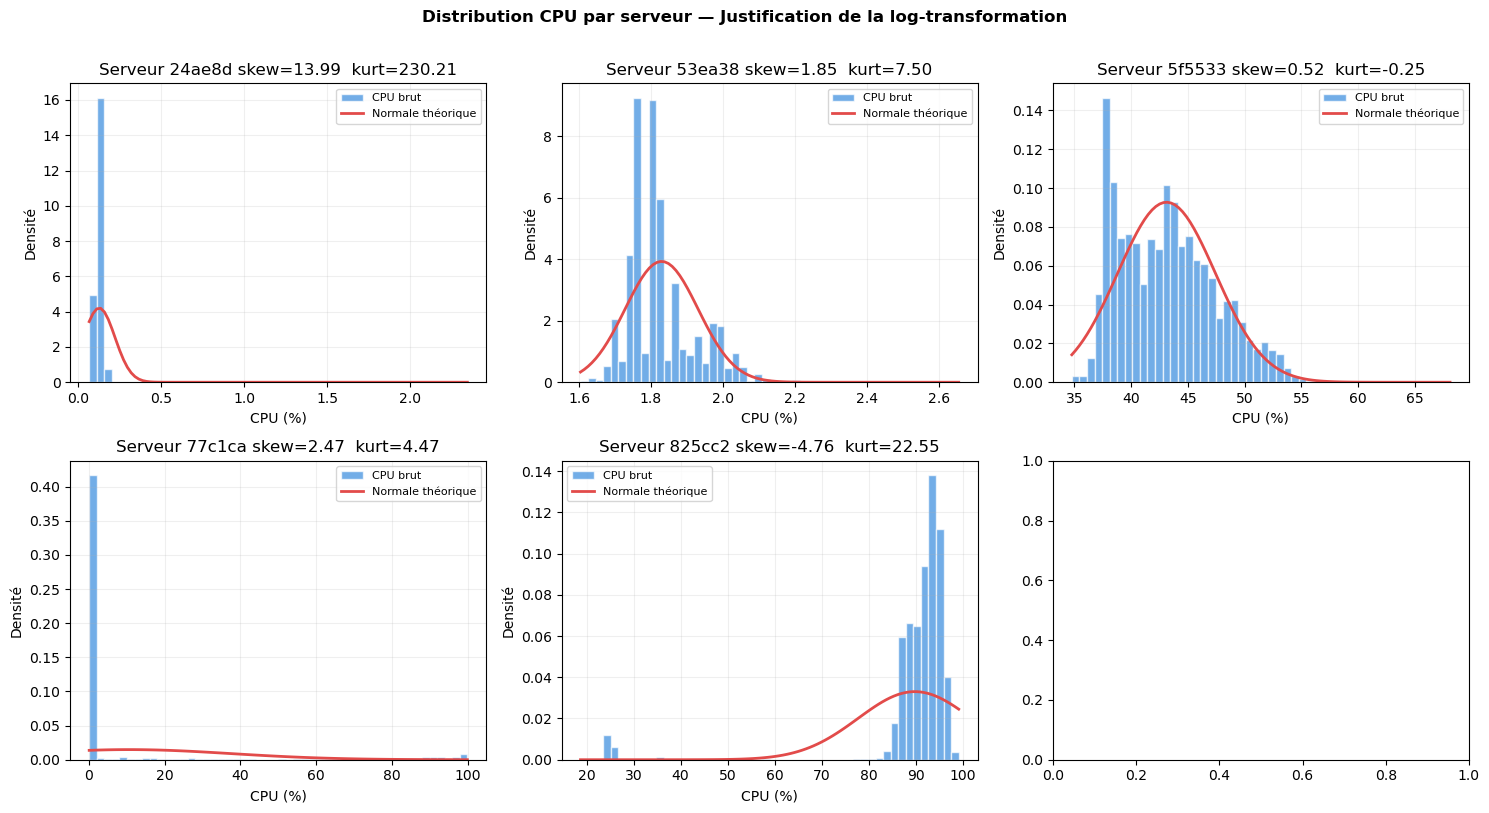


Sauvegardé : distribution_cpu.png
→ Skewness > 1 → distribution asymétrique → log1p justifiée en phase 2


In [31]:
# ── Distribution CPU + test de normalité ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

print("=" * 65)
print("   DISTRIBUTION CPU ET NORMALITÉ PAR SERVEUR")
print("=" * 65)
print(f"{'Serveur':10s}  {'Skewness':10s}  {'Kurtosis':10s}  {'Shapiro-p':10s}  Distrib.   Log1p?")
print("-" * 65)

for i, srv in enumerate(sorted(full_df['serveur_id'].unique())):
    serie = full_df[full_df['serveur_id'] == srv]['value'].dropna()
    sample = serie.sample(min(5000, len(serie)), random_state=42)
    
    skew = serie.skew()
    kurt = serie.kurtosis()
    _, shapiro_p = stats.shapiro(sample)
    
    normale = "normale" if shapiro_p > 0.05 else "non normale"
    need_log = "OUI" if abs(skew) > 1 else "non"
    
    print(f"{srv:10s}  {skew:10.3f}  {kurt:10.3f}  {shapiro_p:10.4f}  {normale:10s}  {need_log}")
    
    # Histogramme
    axes[i].hist(serie, bins=50, alpha=0.7, color='#378ADD',
                 edgecolor='white', density=True, label='CPU brut')
    # Courbe normale théorique
    x = np.linspace(serie.min(), serie.max(), 100)
    axes[i].plot(x, stats.norm.pdf(x, serie.mean(), serie.std()),
                 color='#E24B4A', lw=2, label='Normale théorique')
    axes[i].set_title(f'Serveur {srv} skew={skew:.2f}  kurt={kurt:.2f}')
    axes[i].set_xlabel('CPU (%)')
    axes[i].set_ylabel('Densité')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.2)

plt.suptitle('Distribution CPU par serveur — Justification de la log-transformation',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribution_cpu.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSauvegardé : distribution_cpu.png")
print("→ Skewness > 1 → distribution asymétrique → log1p justifiée en phase 2")


## Analyse comparative inter-serveurs

Boxplot et heatmap de corrélation pour comparer les comportements CPU entre les 5 serveurs et vérifier leur indépendance — hypothèse importante pour le pipeline multi-serveurs.

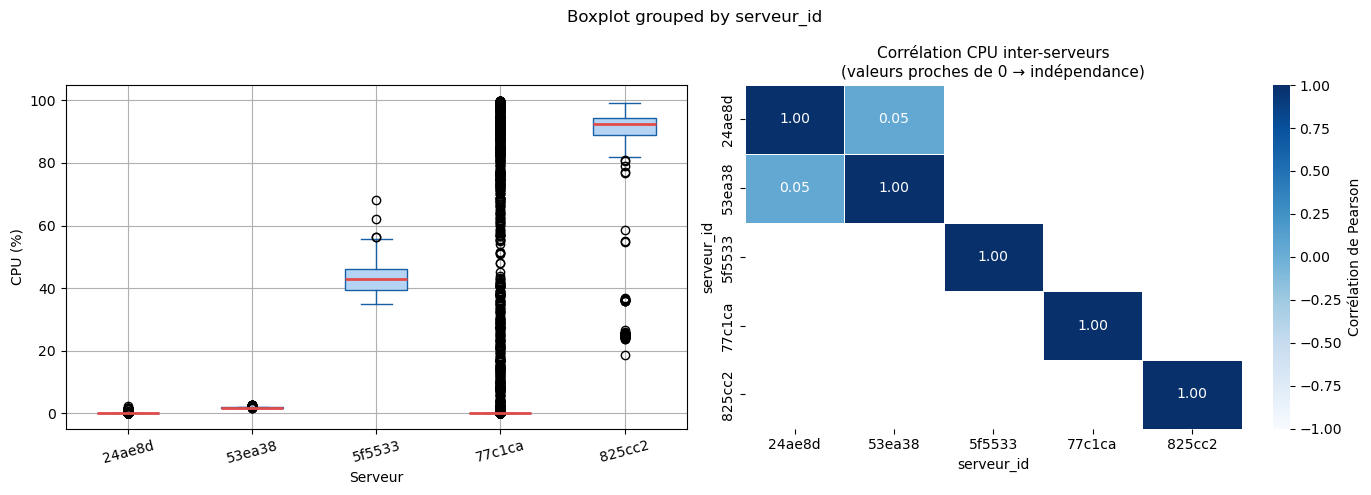

Sauvegardé : comparaison_interserveurs.png

=== Stats descriptives par serveur ===
            Moyenne    Std    Min    Max  Médiane  N_zéros  N_saturés(≥90%)
serveur_id                                                                 
24ae8d         0.13   0.09   0.07   2.34     0.13        0                0
53ea38         1.83   0.10   1.60   2.66     1.80        0                0
5f5533        43.11   4.30  34.77  68.09    42.92        0                0
77c1ca        10.52  26.93   0.06  99.90     0.10        0              195
825cc2        89.79  12.08  18.72  99.12    92.45        0             2808

→ Diversité confirmée : les serveurs ont des profils comportementaux différents
  → Justifie la fusion pour améliorer la généralisation des modèles


In [32]:
# ── Boxplot comparatif + corrélation croisée ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
full_df.boxplot(column='value', by='serveur_id', ax=axes[0],
                patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                medianprops=dict(color='#E24B4A', linewidth=2),
                whiskerprops=dict(color='#185FA5'),
                capprops=dict(color='#185FA5'))
axes[0].set_title('Distribution CPU par serveur', fontsize=11)
axes[0].set_xlabel('Serveur')
axes[0].set_ylabel('CPU (%)')
plt.sca(axes[0])
plt.xticks(rotation=15)
plt.title('')

# Heatmap corrélation croisée
pivot = full_df.pivot_table(index='timestamp', columns='serveur_id', values='value')
corr_matrix = pivot.corr()

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='Blues', ax=axes[1],
            vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Corrélation de Pearson'})
axes[1].set_title('Corrélation CPU inter-serveurs\n(valeurs proches de 0 → indépendance)', fontsize=11)

plt.tight_layout()
plt.savefig('comparaison_interserveurs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : comparaison_interserveurs.png")

# Stats descriptives comparées
print("\n=== Stats descriptives par serveur ===")
stats_df = full_df.groupby('serveur_id')['value'].agg(
    ['mean','std','min','max','median',
     lambda x: (x==0).sum(),
     lambda x: (x>=90).sum()]
).round(2)
stats_df.columns = ['Moyenne','Std','Min','Max','Médiane','N_zéros','N_saturés(≥90%)']
print(stats_df.to_string())
print("\n→ Diversité confirmée : les serveurs ont des profils comportementaux différents")
print("  → Justifie la fusion pour améliorer la généralisation des modèles")


## Profil temporel — charge par heure et jour de semaine

Cette analyse justifie directement l'utilisation des **features temporelles cycliques** (sin/cos de l'heure et du jour) en phase 2. Un motif jour/nuit ou semaine/week-end confirme que le temps est un prédicteur utile.

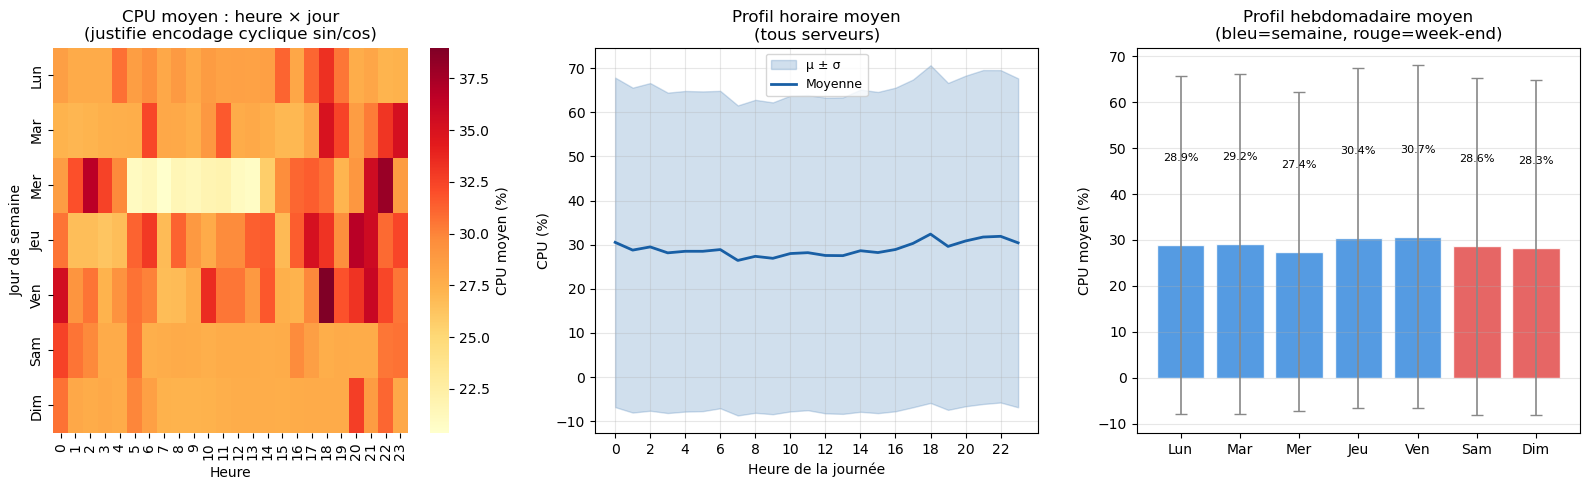

Sauvegardé : profil_temporel.png
→ Motif temporel confirmé → features hour_sin/cos et weekday_sin/cos justifiées


In [33]:
# ── Profil horaire et hebdomadaire ───────────────────────────────────────
df_time = full_df.copy()
df_time['hour']    = df_time['timestamp'].dt.hour
df_time['weekday'] = df_time['timestamp'].dt.dayofweek
jours = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Heatmap heure × jour
pivot_hw = df_time.groupby(['weekday','hour'])['value'].mean().unstack()
sns.heatmap(pivot_hw, ax=axes[0], cmap='YlOrRd',
            yticklabels=jours, xticklabels=range(24),
            cbar_kws={'label': 'CPU moyen (%)'})
axes[0].set_title('CPU moyen : heure × jour\n(justifie encodage cyclique sin/cos)')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Jour de semaine')

# Profil horaire moyen ± std
hourly = df_time.groupby('hour')['value'].agg(['mean','std'])
axes[1].fill_between(hourly.index,
                     hourly['mean'] - hourly['std'],
                     hourly['mean'] + hourly['std'],
                     alpha=0.2, color='#185FA5', label='μ ± σ')
axes[1].plot(hourly.index, hourly['mean'],
             color='#185FA5', lw=2, label='Moyenne')
axes[1].set_title('Profil horaire moyen\n(tous serveurs)')
axes[1].set_xlabel('Heure de la journée')
axes[1].set_ylabel('CPU (%)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Profil hebdomadaire
weekly = df_time.groupby('weekday')['value'].agg(['mean','std'])
colors_w = ['#378ADD']*5 + ['#E24B4A']*2
bars = axes[2].bar(range(7), weekly['mean'],
                   yerr=weekly['std'], capsize=4,
                   color=colors_w, alpha=0.85, edgecolor='white',
                   error_kw={'elinewidth': 1.2, 'ecolor': '#888'})
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(jours)
axes[2].set_title('Profil hebdomadaire moyen\n(bleu=semaine, rouge=week-end)')
axes[2].set_ylabel('CPU moyen (%)')
axes[2].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, weekly['mean']):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+weekly['std'].mean()*0.5,
                 f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('profil_temporel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : profil_temporel.png")
print("→ Motif temporel confirmé → features hour_sin/cos et weekday_sin/cos justifiées")


## Analyse des comportements extrêmes

Identification des pics de saturation (CPU ≥ 90%) et des périodes creuses (CPU = 0). Ces valeurs extrêmes sont précisément les **anomalies cibles** de la phase 4.

   ANALYSE DES COMPORTEMENTS EXTRÊMES
Serveur     CPU≥90%     CPU=0     CPU>mean+3σ     Comportement
-----------------------------------------------------------------
24ae8d         0 (0.0%)     0 (0.0%)    16 (0.4%)       Charge modérée
53ea38         0 (0.0%)     0 (0.0%)    32 (0.8%)       Charge modérée
5f5533         0 (0.0%)     0 (0.0%)     4 (0.1%)       Charge modérée
77c1ca       195 (4.8%)     0 (0.0%)   176 (4.4%)       Charge modérée
825cc2      2808 (69.6%)     0 (0.0%)     0 (0.0%)       Charge élevée fréquente


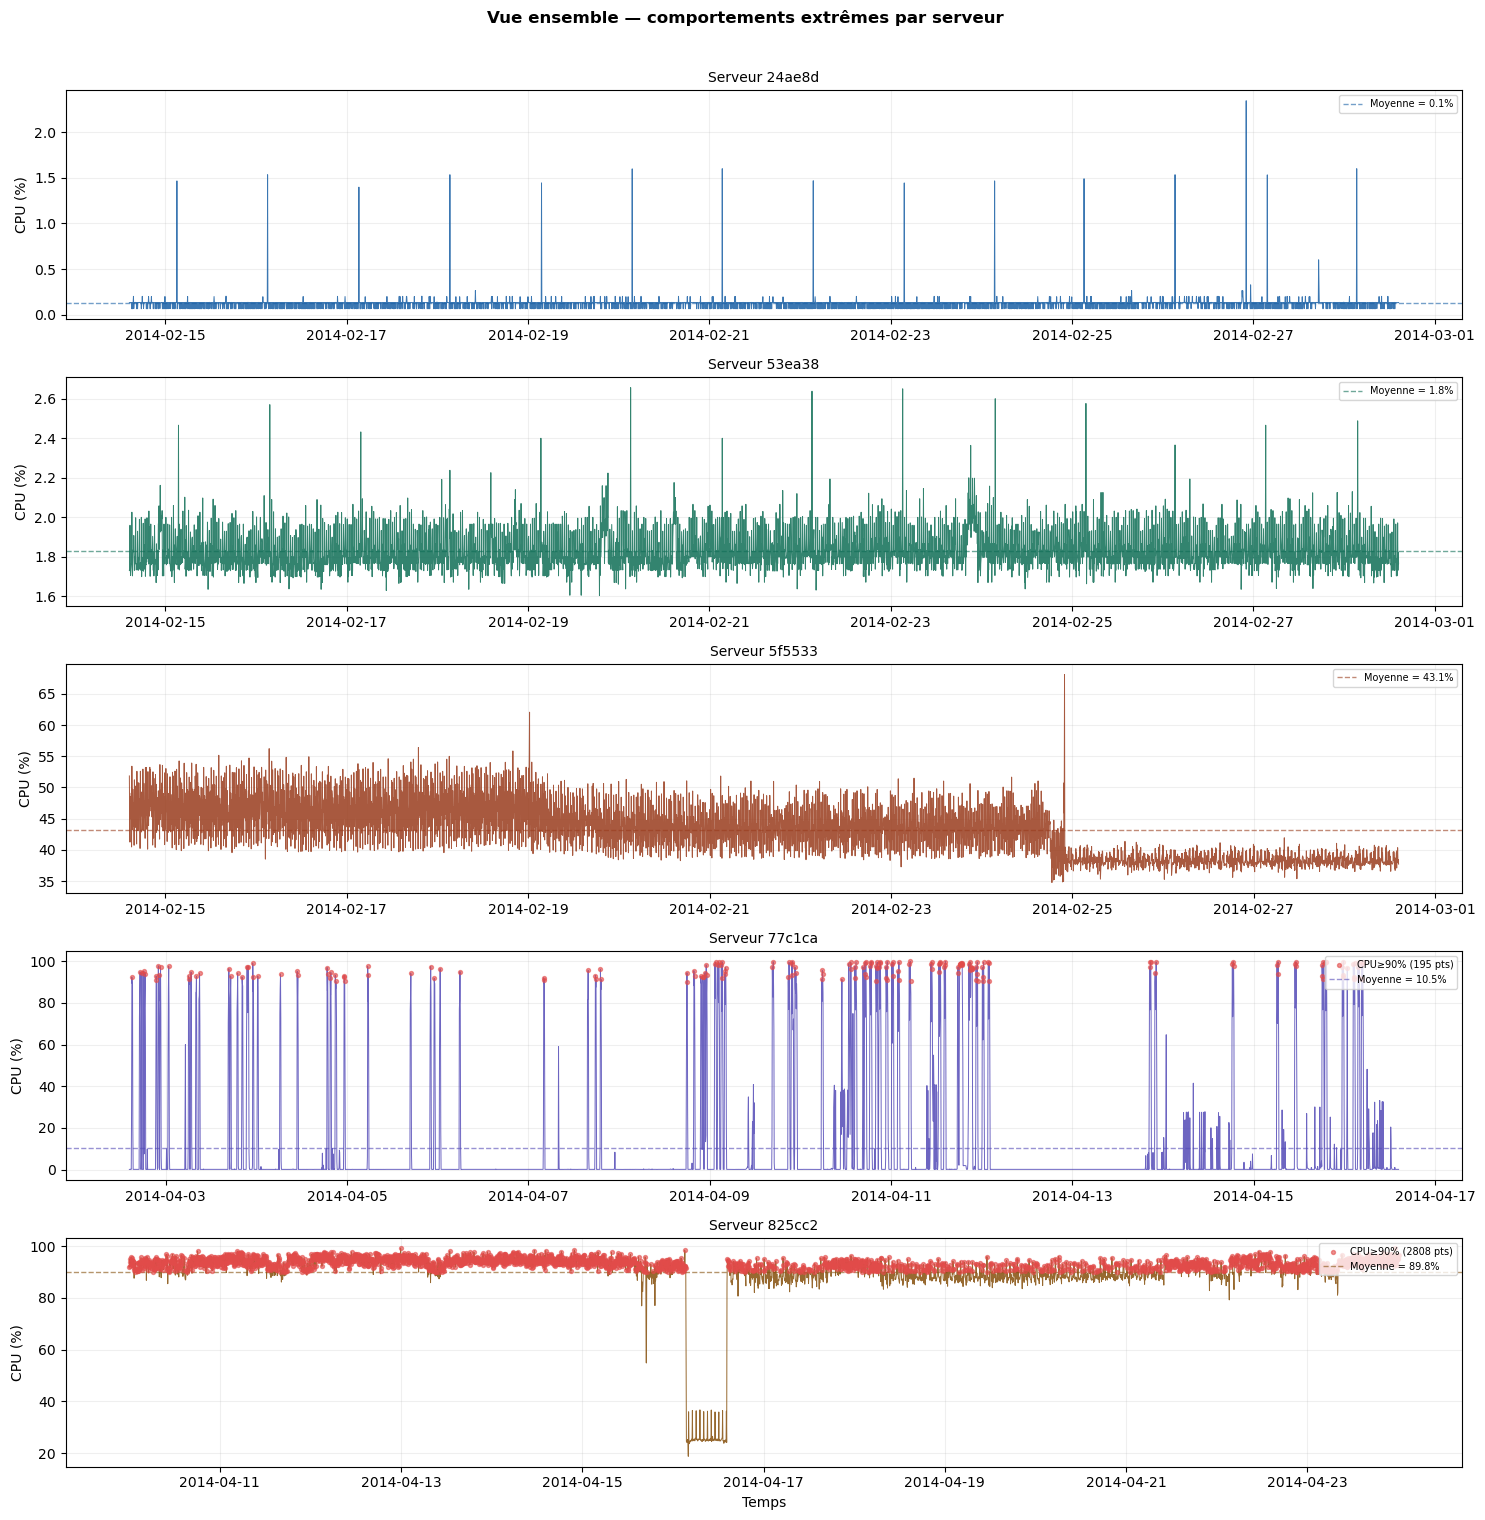

Sauvegardé : comportements_extremes.png
→ Les pics CPU≥90% correspondent aux anomalies à détecter en phase 4


In [34]:
# ── Analyse des valeurs extrêmes par serveur ─────────────────────────────
print("=" * 65)
print("   ANALYSE DES COMPORTEMENTS EXTRÊMES")
print("=" * 65)
print(f"{'Serveur':10s}  {'CPU≥90%':10s}  {'CPU=0':8s}  {'CPU>mean+3σ':14s}  Comportement")
print("-" * 65)

for srv in sorted(full_df['serveur_id'].unique()):
    serie = full_df[full_df['serveur_id'] == srv]['value']
    n = len(serie)
    
    n_haut  = (serie >= 90).sum()
    n_zero  = (serie == 0).sum()
    seuil3s = serie.mean() + 3*serie.std()
    n_3s    = (serie > seuil3s).sum()
    
    if n_haut/n > 0.05:
        comportement = "Charge élevée fréquente"
    elif n_zero/n > 0.01:
        comportement = "Arrêts fréquents"
    else:
        comportement = "Charge modérée"
    
    print(f"{srv:10s}  {n_haut:4d} ({n_haut/n*100:.1f}%)  "
          f"{n_zero:4d} ({n_zero/n*100:.1f}%)  "
          f"{n_3s:4d} ({n_3s/n*100:.1f}%)       {comportement}")

# Visualisation multi-série superposée
fig, axes = plt.subplots(len(full_df['serveur_id'].unique()), 1,
                          figsize=(15, 3*len(full_df['serveur_id'].unique())),
                          sharex=False)

couleurs = ['#185FA5','#0F6E56','#993C1D','#534AB7','#854F0B']

for i, srv in enumerate(sorted(full_df['serveur_id'].unique())):
    df_s = full_df[full_df['serveur_id'] == srv].sort_values('timestamp')
    
    axes[i].plot(df_s['timestamp'], df_s['value'],
                 color=couleurs[i], lw=0.7, alpha=0.85)
    
    # Zone de saturation
    pts_haut = df_s[df_s['value'] >= 90]
    if len(pts_haut) > 0:
        axes[i].scatter(pts_haut['timestamp'], pts_haut['value'],
                        color='#E24B4A', s=8, zorder=5, alpha=0.6,
                        label=f'CPU≥90% ({len(pts_haut)} pts)')
    
    axes[i].axhline(y=df_s['value'].mean(), color=couleurs[i],
                    ls='--', lw=1, alpha=0.6,
                    label=f'Moyenne = {df_s["value"].mean():.1f}%')
    axes[i].set_title(f'Serveur {srv}', fontsize=10)
    axes[i].set_ylabel('CPU (%)')
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].grid(alpha=0.2)

axes[-1].set_xlabel('Temps')
plt.suptitle('Vue ensemble — comportements extrêmes par serveur',fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comportements_extremes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : comportements_extremes.png")
print("→ Les pics CPU≥90% correspondent aux anomalies à détecter en phase 4")


## Synthèse — Phase 1 Exploration

Cette phase d'exploration a établi les fondements analytiques du projet :

**Dataset :**
- 5 serveurs AWS EC2 fusionnés → 32 256 observations × 3 colonnes
- Fréquence d'échantillonnage : 5 minutes (confirmée)
- Couverture : ~14 jours par serveur

**Résultats clés :**
- Distributions non normales (skewness élevé) → **justifie log1p en phase 2**
- Motif temporel heure/jour confirmé → **justifie encodage cyclique sin/cos en phase 2**
- Fréquence 5 min confirmée → **justifie rolling_5 (25 min) et rolling_10 (50 min) en phase 2**
- Comportements hétérogènes inter-serveurs → **justifie traitement par serveur indépendant**
- Pics CPU≥90% identifiés → **définit les cibles de détection pour la phase 4**
